# Face-to-BMI Modeling

Goal: predict BMI from face images and compare each model using the same validation/test split. The paper reports Pearson `r = 0.65` overall, `0.71` male, and `0.57` female, so Pearson `r` is the main comparison metric. MAE and RMSE are also reported so the BMI error is interpretable.

Notebook flow:

1. Prepare the data and shared helper functions.
2. Run Keras transfer-learning experiments one at a time.
3. Display each experiment's train/validation/test results immediately after it runs.
4. Keep simple baselines as optional sanity checks, not as headline experiments.

Notes:

Experiment 4 is face-specific: VGGFace2-pretrained FaceNet/InceptionResnetV1 with fine-tuning. It uses PyTorch because the most reliable face-pretrained weights are distributed that way.

The sequence is: EfficientNetB1 with last 10 layers unfrozen, ResNet50 with last 10 layers unfrozen, EfficientNetB1 with last 30 layers unfrozen, VGGFace2 FaceNet fine-tuning, optional train-mean baseline, optional ground-truth-gender mean baseline, and final regression plus paper-style pairwise comparison.

Important comparison note: the paper split has 838 test labels. If the local image folder is missing some files, the notebook reports that gap and evaluates image models only on the available-image test subset. Restore the full image archive to make the test image count match the paper exactly.

## 1. Setup

In [8]:
from pathlib import Path
import json
import math
import os
import random
import time
import re
import zipfile
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.applications import EfficientNetB1, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


COLAB_PROJECT_DIR = Path('/content/drive/MyDrive/ML2 Final Project')
LOCAL_PROJECT_DIR = Path('/Users/satanhaha/Documents/MS ADS/ML2/Final Project')


def mount_google_drive():
    if COLAB_PROJECT_DIR.exists():
        return
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except ModuleNotFoundError:
        pass


def find_project_dir():
    mount_google_drive()
    cwd = Path.cwd().resolve()
    candidates = [COLAB_PROJECT_DIR, cwd, *cwd.parents, LOCAL_PROJECT_DIR]
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'BMI.zip').exists() or (candidate / 'eda_outputs').exists():
            return candidate
        if (candidate / 'BMI' / 'Data').exists() and ((candidate / 'eda_outputs').exists() or (candidate / 'Nyssa' / 'eda_outputs').exists()):
            return candidate
        if candidate.name == 'Nyssa' and (candidate.parent / 'BMI' / 'Data').exists():
            return candidate.parent
    searched = '\n'.join(str(c) for c in candidates)
    raise FileNotFoundError(f'Could not find project directory. Checked:\n{searched}')


PROJECT_DIR = find_project_dir()
BMI_ZIP = PROJECT_DIR / 'BMI.zip'
DATA_CANDIDATES = [PROJECT_DIR / 'BMI' / 'Data', PROJECT_DIR / 'Data']
if not any(p.exists() for p in DATA_CANDIDATES) and BMI_ZIP.exists():
    with zipfile.ZipFile(BMI_ZIP) as zf:
        zf.extractall(PROJECT_DIR)

DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), DATA_CANDIDATES[0])
IMAGE_DIR = DATA_DIR / 'Images'
if not IMAGE_DIR.exists():
    checked = '\n'.join(str(p / 'Images') for p in DATA_CANDIDATES)
    raise FileNotFoundError(
        'Could not find the image folder. Make sure BMI.zip is in the project folder or already extracted. Checked:\n'
        f'{checked}'
    )

AUDIT_CANDIDATES = [
    PROJECT_DIR / 'eda_outputs' / 'image_quality_audit.csv',
    PROJECT_DIR / 'Nyssa' / 'eda_outputs' / 'image_quality_audit.csv',
]
AUDIT_PATH = next((p for p in AUDIT_CANDIDATES if p.exists()), AUDIT_CANDIDATES[0])
if not AUDIT_PATH.exists():
    checked = '\n'.join(str(p) for p in AUDIT_CANDIDATES)
    raise FileNotFoundError(
        'Could not find image_quality_audit.csv. Re-run EDA.ipynb or check these paths:\n'
        f'{checked}'
    )

MODEL_DIR = AUDIT_PATH.parents[1] / 'model_outputs'
EXPERIMENT_DIR = MODEL_DIR / 'experiments'
PREDICTION_DIR = EXPERIMENT_DIR / 'predictions'
CONFIG_DIR = EXPERIMENT_DIR / 'configs'
PAIRWISE_DIR = EXPERIMENT_DIR / 'paper_style_pairwise'
RESULTS_PATH = EXPERIMENT_DIR / 'experiment_results.csv'
for directory in [MODEL_DIR, EXPERIMENT_DIR, PREDICTION_DIR, CONFIG_DIR, PAIRWISE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')

print(f'PROJECT_DIR: {PROJECT_DIR}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'IMAGE_DIR: {IMAGE_DIR}')
print(f'AUDIT_PATH: {AUDIT_PATH}')
print(f'MODEL_DIR: {MODEL_DIR}')
print(f'PAIRWISE_DIR: {PAIRWISE_DIR}')
print(f'Audit exists: {AUDIT_PATH.exists()}')

GPUS = tf.config.list_physical_devices('GPU')
print(f'TensorFlow GPUs: {GPUS}')


PROJECT_DIR: /content/drive/MyDrive/ML2 Final Project
DATA_DIR: /content/drive/MyDrive/ML2 Final Project/BMI/Data
IMAGE_DIR: /content/drive/MyDrive/ML2 Final Project/BMI/Data/Images
AUDIT_PATH: /content/drive/MyDrive/ML2 Final Project/eda_outputs/image_quality_audit.csv
MODEL_DIR: /content/drive/MyDrive/ML2 Final Project/model_outputs
PAIRWISE_DIR: /content/drive/MyDrive/ML2 Final Project/model_outputs/experiments/paper_style_pairwise
Audit exists: True
TensorFlow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
print(f'PROJECT_DIR: {PROJECT_DIR}')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')
print(f'IMAGE_DIR exists: {IMAGE_DIR.exists()}')
print(f'AUDIT_PATH exists: {AUDIT_PATH.exists()}')
print(f'MODEL_DIR: {MODEL_DIR}')


PROJECT_DIR: /content/drive/MyDrive/ML2 Final Project
DATA_DIR exists: True
IMAGE_DIR exists: True
AUDIT_PATH exists: True
MODEL_DIR: /content/drive/MyDrive/ML2 Final Project/model_outputs


## 2. Load Clean Rows and Make a Pair-Safe Validation Split

Preprocessing decisions from EDA:

- Keep the paper/provided train-test split from `data.csv`.
- Report both the original paper split counts and the usable-image counts after dropping missing/unreadable files.
- Drop missing/unreadable images for model training and image-based evaluation, because the model cannot infer BMI from files that are not present.
- Create validation only from training rows, grouped by inferred `pair_id` so before/after images do not split across train and validation.
- Keep final test labels untouched until model selection is done.


In [10]:
LABEL_PATH = DATA_DIR / 'data.csv'
raw_labels = pd.read_csv(LABEL_PATH)
raw_labels['gender'] = raw_labels['gender'].astype(str).str.strip()
raw_labels['split'] = np.where(raw_labels['is_training'].astype(int).eq(1), 'train', 'test')
raw_labels['image_path'] = raw_labels['name'].apply(lambda name: IMAGE_DIR / str(name))
raw_labels['actual_file_exists'] = raw_labels['image_path'].apply(lambda p: Path(p).exists())

paper_train_rows = int(raw_labels['split'].eq('train').sum())
paper_test_rows = int(raw_labels['split'].eq('test').sum())
missing_train_images = int(raw_labels.loc[raw_labels['split'].eq('train'), 'actual_file_exists'].eq(False).sum())
missing_test_images = int(raw_labels.loc[raw_labels['split'].eq('test'), 'actual_file_exists'].eq(False).sum())

paper_split_summary = raw_labels.groupby('split').agg(
    paper_rows=('name', 'size'),
    available_image_files=('actual_file_exists', 'sum'),
    missing_image_files=('actual_file_exists', lambda s: int((~s).sum())),
    male_rows=('gender', lambda s: int(s.eq('Male').sum())),
    female_rows=('gender', lambda s: int(s.eq('Female').sum())),
    bmi_mean=('bmi', 'mean'),
    bmi_std=('bmi', 'std'),
).reindex(['train', 'test']).round(3)
display(paper_split_summary)

missing_test_preview = raw_labels.loc[
    raw_labels['split'].eq('test') & raw_labels['actual_file_exists'].eq(False),
    ['name', 'gender', 'bmi', 'image_path'],
]
if len(missing_test_preview):
    print(
        f'The paper split has {paper_test_rows} test labels, but {missing_test_images} test image files are missing locally. '
        'Image-based test metrics below therefore use the available-image subset unless the full image archive is restored.'
    )
    display(missing_test_preview.head(12))

eda = pd.read_csv(AUDIT_PATH)
eda['image_path'] = eda['name'].apply(lambda name: IMAGE_DIR / str(name))
eda['readable'] = eda['readable'].astype(bool)
eda['actual_file_exists'] = eda['image_path'].apply(lambda p: Path(p).exists())

missing_before = eda.loc[eda['readable'] & ~eda['actual_file_exists'], 'image_path']
if len(missing_before) and BMI_ZIP.exists():
    print(f'{len(missing_before)} readable rows point to files missing from Drive. Re-extracting BMI.zip...')
    with zipfile.ZipFile(BMI_ZIP) as zf:
        zf.extractall(PROJECT_DIR)
    eda['actual_file_exists'] = eda['image_path'].apply(lambda p: Path(p).exists())
    raw_labels['actual_file_exists'] = raw_labels['image_path'].apply(lambda p: Path(p).exists())

missing_after = eda.loc[eda['readable'] & ~eda['actual_file_exists'], 'image_path']
if len(missing_after):
    print(f'Dropping {len(missing_after)} audit-readable rows because the image files are still missing:')
    display(missing_after.head(10).to_frame('missing_image_path'))

df = eda.loc[eda['readable'] & eda['actual_file_exists']].copy().reset_index(drop=True)
if df.empty:
    raise FileNotFoundError('No readable image files were found. Check that BMI.zip extracted into BMI/Data/Images in Google Drive.')
df['gender'] = df['gender'].astype(str).str.strip()
df['split'] = np.where(df['is_training'].astype(int).eq(1), 'train', 'test')
df['pair_id'] = df['pair_id'].astype(int)

train_full = df[df['split'] == 'train'].copy().reset_index(drop=True)
test_df = df[df['split'] == 'test'].copy().reset_index(drop=True)
evaluation_scope = 'full-paper-test' if len(test_df) == paper_test_rows else 'available-image-test-subset'

gss = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=SEED)
train_idx, val_idx = next(gss.split(train_full, groups=train_full['pair_id']))
train_df = train_full.iloc[train_idx].copy().reset_index(drop=True)
val_df = train_full.iloc[val_idx].copy().reset_index(drop=True)

target_mean = train_df['bmi'].mean()
target_std = train_df['bmi'].std()

usable_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'usable_rows': [len(train_df), len(val_df), len(test_df)],
    'paper_rows_before_image_filter': [paper_train_rows, np.nan, paper_test_rows],
    'pairs': [train_df['pair_id'].nunique(), val_df['pair_id'].nunique(), test_df['pair_id'].nunique()],
    'bmi_mean': [train_df['bmi'].mean(), val_df['bmi'].mean(), test_df['bmi'].mean()],
    'bmi_std': [train_df['bmi'].std(), val_df['bmi'].std(), test_df['bmi'].std()],
    'male_rows': [(train_df['gender'] == 'Male').sum(), (val_df['gender'] == 'Male').sum(), (test_df['gender'] == 'Male').sum()],
    'female_rows': [(train_df['gender'] == 'Female').sum(), (val_df['gender'] == 'Female').sum(), (test_df['gender'] == 'Female').sum()],
}).round(3)
display(usable_summary)
print(f'Evaluation scope: {evaluation_scope}')

assert set(train_df['pair_id']).isdisjoint(set(val_df['pair_id']))
assert set(train_full['pair_id']).isdisjoint(set(test_df['pair_id']))


,paper_rows,available_image_files,missing_image_files,male_rows,female_rows,bmi_mean,bmi_std
split,,,,,,,
train,3368,3210,158,1978,1390,32.533,8.048
test,838,752,86,460,378,33.855,9.168


The paper split has 838 test labels, but 86 test image files are missing locally. Image-based test metrics below therefore use the available-image subset unless the full image archive is restored.


,name,gender,bmi,image_path
3368,img_3368.bmp,Male,35.258488,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3376,img_3376.bmp,Female,57.160838,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3377,img_3377.bmp,Female,41.500334,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3387,img_3387.bmp,Female,32.609863,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3394,img_3394.bmp,Male,39.047808,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3404,img_3404.bmp,Male,32.546296,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3405,img_3405.bmp,Male,24.409722,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3408,img_3408.bmp,Male,48.684211,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3409,img_3409.bmp,Male,37.973684,/content/drive/MyDrive/ML2 Final Project/BMI/D...
3424,img_3424.bmp,Male,41.742578,/content/drive/MyDrive/ML2 Final Project/BMI/D...


,split,usable_rows,paper_rows_before_image_filter,pairs,bmi_mean,bmi_std,male_rows,female_rows
0,train,2635,3368.0,1327,32.540,8.035,1592,1043
1,val,575,NaN,292,31.950,7.923,335,240
2,test,752,838.0,384,33.698,9.220,427,325


Evaluation scope: available-image-test-subset


## 3. Keras Dataset Settings

All main experiments use the same Keras `tf.data` image pipeline so the comparisons are easier to read and explain.


In [11]:
BATCH_SIZE = 32
INPUT_SIZE = 240
KERAS_IMG_SIZE = (INPUT_SIZE, INPUT_SIZE)
KERAS_BATCH_SIZE = BATCH_SIZE
AUTOTUNE = tf.data.AUTOTUNE


## 4. Metrics and Saved Results

Use Pearson `r` for direct paper comparison, but also report MAE/RMSE so you can tell whether a model is numerically useful. Every call to `add_result(...)` writes three artifacts under `model_outputs/experiments`:

- `experiment_results.csv`: one row per model/split result.
- `predictions/*.csv`: row-level predictions for error analysis.
- `configs/*.json`: model settings used for that run.

Each experiment below logs train, validation, and test rows, then displays only that experiment's results.


In [12]:
leaderboard = []

RESULT_COLUMNS = [
    'run_id', 'model', 'method', 'backbone', 'pretrained_source', 'estimator', 'split', 'n',
    'mae', 'rmse', 'pearson_r', 'pearson_male', 'pearson_female', 'input_size',
    'train_rows', 'val_rows', 'test_rows', 'paper_train_rows', 'paper_test_rows',
    'missing_train_images', 'missing_test_images', 'evaluation_scope',
    'prediction_path', 'config_path', 'notes', 'created_at'
]


def slugify(value):
    value = str(value).strip().lower()
    value = re.sub(r'[^a-z0-9]+', '_', value)
    return value.strip('_') or 'run'


def json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    return value


def load_experiment_results():
    if RESULTS_PATH.exists():
        return pd.read_csv(RESULTS_PATH)
    return pd.DataFrame(columns=RESULT_COLUMNS)


def save_experiment_results(results):
    for col in RESULT_COLUMNS:
        if col not in results.columns:
            results[col] = np.nan
    results[RESULT_COLUMNS].to_csv(RESULTS_PATH, index=False)


def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def metric_row(model_name, split_name, frame, preds, notes='', metadata=None):
    metadata = metadata or {}
    y = frame['bmi'].to_numpy(float)
    preds = np.asarray(preds, dtype=float)
    male_mask = frame['gender'].eq('Male').to_numpy()
    female_mask = frame['gender'].eq('Female').to_numpy()
    out = {
        'model': model_name,
        'method': metadata.get('method', ''),
        'backbone': metadata.get('backbone', ''),
        'pretrained_source': metadata.get('pretrained_source', ''),
        'estimator': metadata.get('estimator', ''),
        'split': split_name,
        'n': len(frame),
        'mae': mean_absolute_error(y, preds),
        'rmse': rmse_score(y, preds),
        'pearson_r': pearson_r(y, preds),
        'pearson_male': pearson_r(y[male_mask], preds[male_mask]),
        'pearson_female': pearson_r(y[female_mask], preds[female_mask]),
        'input_size': metadata.get('input_size', INPUT_SIZE),
        'train_rows': len(train_df),
        'val_rows': len(val_df),
        'test_rows': len(test_df),
        'paper_train_rows': globals().get('paper_train_rows', np.nan),
        'paper_test_rows': globals().get('paper_test_rows', np.nan),
        'missing_train_images': globals().get('missing_train_images', np.nan),
        'missing_test_images': globals().get('missing_test_images', np.nan),
        'evaluation_scope': globals().get('evaluation_scope', ''),
        'notes': notes,
        'created_at': datetime.now().isoformat(timespec='seconds'),
    }
    return out


def add_result(model_name, split_name, frame, preds, notes='', run_id=None, metadata=None, config=None, save_predictions=True):
    metadata = metadata or {}
    config = config or {}
    run_id = run_id or f"{RUN_TAG}_{slugify(model_name)}"
    row = metric_row(model_name, split_name, frame, preds, notes=notes, metadata=metadata)
    row['run_id'] = run_id

    if save_predictions:
        pred_frame = frame[['name', 'bmi', 'gender', 'split', 'pair_id']].copy()
        pred_frame['model'] = model_name
        pred_frame['run_id'] = run_id
        pred_frame['pred_bmi'] = np.asarray(preds, dtype=float)
        pred_frame['error'] = pred_frame['pred_bmi'] - pred_frame['bmi']
        pred_path = PREDICTION_DIR / f"{run_id}_{split_name}_predictions.csv"
        pred_frame.to_csv(pred_path, index=False)
        row['prediction_path'] = str(pred_path)
    else:
        row['prediction_path'] = ''

    full_config = {
        'run_id': run_id,
        'model': model_name,
        'split_logged': split_name,
        'metadata': metadata,
        'config': config,
        'data': {
            'train_rows': len(train_df),
            'val_rows': len(val_df),
            'test_rows': len(test_df),
            'target_mean': target_mean,
            'target_std': target_std,
            'paper_train_rows': globals().get('paper_train_rows', np.nan),
            'paper_test_rows': globals().get('paper_test_rows', np.nan),
            'missing_train_images': globals().get('missing_train_images', np.nan),
            'missing_test_images': globals().get('missing_test_images', np.nan),
            'evaluation_scope': globals().get('evaluation_scope', ''),
        },
    }
    config_path = CONFIG_DIR / f"{run_id}.json"
    config_path.write_text(json.dumps(json_safe(full_config), indent=2))
    row['config_path'] = str(config_path)

    leaderboard.append(row)
    existing = load_experiment_results()
    updated = pd.concat([existing, pd.DataFrame([row])], ignore_index=True)
    save_experiment_results(updated)
    return pd.DataFrame([row])[RESULT_COLUMNS].round(4)


def current_leaderboard():
    if not leaderboard:
        return pd.DataFrame(columns=RESULT_COLUMNS)
    return pd.DataFrame(leaderboard)


def compare_results(split='test', include_current=True, sort_by='pearson_r'):
    results = load_experiment_results()
    if include_current and leaderboard:
        results = pd.concat([results, pd.DataFrame(leaderboard)], ignore_index=True)
    if results.empty:
        return results
    results = results.drop_duplicates(subset=['run_id', 'model', 'split', 'prediction_path'], keep='last')
    results = results[results['split'].eq(split)].copy()
    cols = [
        'run_id', 'model', 'method', 'backbone', 'estimator', 'split', 'n',
        'test_rows', 'paper_test_rows', 'missing_test_images', 'evaluation_scope',
        'mae', 'rmse', 'pearson_r', 'pearson_male', 'pearson_female', 'notes'
    ]
    ascending = sort_by in ['mae', 'rmse']
    return results[cols].sort_values(sort_by, ascending=ascending).reset_index(drop=True).round(4)


def best_by_model(split='test', metric='pearson_r'):
    results = compare_results(split=split, include_current=True, sort_by=metric)
    if results.empty:
        return results
    ascending = metric in ['mae', 'rmse']
    return results.sort_values(metric, ascending=ascending).drop_duplicates('model', keep='first').reset_index(drop=True)


def show_run(run_id):
    results = current_leaderboard()
    if results.empty:
        return results
    cols = ['model', 'method', 'backbone', 'estimator', 'split', 'n', 'mae', 'rmse', 'pearson_r', 'pearson_male', 'pearson_female', 'notes']
    run_results = results[results['run_id'].eq(run_id)].copy()
    run_results['split'] = pd.Categorical(run_results['split'], categories=['train', 'val', 'test'], ordered=True)
    return run_results[cols].sort_values('split').round(4)



def display_prediction_samples(frame, preds, title, n=5, random_state=SEED):
    preds = np.asarray(preds, dtype=float)
    if len(frame) == 0:
        print(f'No rows available for {title}.')
        return
    sample_n = min(n, len(frame))
    sample = frame.reset_index(drop=True).sample(sample_n, random_state=random_state)
    fig, axes = plt.subplots(1, sample_n, figsize=(4 * sample_n, 4))
    if sample_n == 1:
        axes = [axes]
    for ax, (idx, row) in zip(axes, sample.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        pred_bmi = preds[idx]
        true_bmi = float(row['bmi'])
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f"True BMI: {true_bmi:.1f}\nPred BMI: {pred_bmi:.1f}",
            fontsize=10,
        )
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


print(f'Persistent experiment table: {RESULTS_PATH}')
print(f'This notebook run tag: {RUN_TAG}')


Persistent experiment table: /content/drive/MyDrive/ML2 Final Project/model_outputs/experiments/experiment_results.csv
This notebook run tag: 20260522_073954


## Shared Keras Transfer-Learning Helpers

These helpers keep the three neural-network experiments consistent. Each experiment still follows the same visible structure: define `transfer_configs`, train with `model.fit(...)`, collect `results_transfer`, save predictions, and display the result table.


In [13]:
def load_keras_image(path, bmi):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, KERAS_IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, tf.cast(bmi, tf.float32)


def make_keras_dataset(frame, training=False):
    paths = frame['image_path'].astype(str).to_numpy()
    labels = frame['bmi'].astype('float32').to_numpy()
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_keras_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(KERAS_BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_fit_ds = make_keras_dataset(train_df, training=True)
train_eval_ds = make_keras_dataset(train_df, training=False)
val_ds = make_keras_dataset(val_df, training=False)
test_ds = make_keras_dataset(test_df, training=False)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.08),
    layers.RandomFlip('horizontal'),
], name='data_augmentation')


def build_transfer_regressor(backbone_name, unfreeze_last=10, dropout=0.25, dense_units=64):
    backbone_name = backbone_name.lower()
    inputs = keras.Input(shape=(*KERAS_IMG_SIZE, 3))
    x = data_augmentation(inputs)

    if backbone_name == 'efficientnetb1':
        base_model = EfficientNetB1(
            include_top=False,
            weights='imagenet',
            input_shape=(*KERAS_IMG_SIZE, 3),
        )
        x = base_model(x, training=False)
        display_name = 'EfficientNetB1'
    elif backbone_name == 'resnet50':
        base_model = ResNet50(
            include_top=False,
            weights='imagenet',
            input_shape=(*KERAS_IMG_SIZE, 3),
        )
        x = layers.Lambda(resnet50_preprocess_input, name='resnet50_preprocess')(x)
        x = base_model(x, training=False)
        display_name = 'ResNet50'
    else:
        raise ValueError(f'Unknown backbone_name: {backbone_name}')

    for layer in base_model.layers:
        layer.trainable = False
    if unfreeze_last:
        for layer in base_model.layers[-unfreeze_last:]:
            layer.trainable = True

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs, name=f'{display_name}_BMI_Regressor')
    return model, base_model, display_name


def run_transfer_experiment(cfg):
    model, base_model, display_name = build_transfer_regressor(
        cfg['backbone'],
        unfreeze_last=cfg['unfreeze_last'],
        dropout=cfg.get('dropout', 0.25),
        dense_units=cfg.get('dense_units', 64),
    )

    print(f"{display_name}: {len(base_model.layers)} layers")
    base_model.summary()
    model.summary()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate']),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[
            keras.metrics.MeanAbsoluteError(name='mae'),
            keras.metrics.RootMeanSquaredError(name='rmse'),
        ],
    )

    log_dir = str(MODEL_DIR / 'logs' / cfg['name'])
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
        TensorBoard(log_dir=log_dir),
    ]

    start_train_time = time.time()
    history = model.fit(
        train_fit_ds,
        validation_data=val_ds,
        epochs=cfg['epochs'],
        callbacks=callbacks,
        verbose=1,
    )
    training_time = time.time() - start_train_time

    sample_images, _ = next(iter(test_ds))
    start_time = time.time()
    model.predict(sample_images, verbose=0)
    inference_time = (time.time() - start_time) / len(sample_images)

    train_loss, train_mae, train_rmse = model.evaluate(train_eval_ds, verbose=0)
    val_loss, val_mae, val_rmse = model.evaluate(val_ds, verbose=0)
    test_loss, test_mae, test_rmse = model.evaluate(test_ds, verbose=0)

    train_pred = model.predict(train_eval_ds, verbose=0).ravel()
    val_pred = model.predict(val_ds, verbose=0).ravel()
    test_pred = model.predict(test_ds, verbose=0).ravel()

    result = {
        'model': cfg['name'],
        'backbone': cfg['backbone'],
        'unfreeze_last': cfg['unfreeze_last'],
        'train_loss': train_loss,
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_pearson_r': pearson_r(train_df['bmi'], train_pred),
        'best_val_loss': np.min(history.history['val_loss']),
        'best_val_mae': np.min(history.history['val_mae']),
        'best_val_rmse': np.min(history.history['val_rmse']),
        'val_pearson_r': pearson_r(val_df['bmi'], val_pred),
        'test_loss': test_loss,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_pearson_r': pearson_r(test_df['bmi'], test_pred),
        'inference_time_per_image_sec': inference_time,
        'training_time_sec': training_time,
    }
    predictions = {'train': train_pred, 'val': val_pred, 'test': test_pred}
    return model, history, result, predictions


def save_transfer_experiment(run_id, model_name, cfg, model, result, predictions):
    metadata = {
        'method': 'transfer_learning_cnn',
        'backbone': cfg['backbone'],
        'pretrained_source': 'keras_imagenet',
        'estimator': 'linear_regression_head',
        'input_size': KERAS_IMG_SIZE[0],
    }
    model_path = MODEL_DIR / f'{run_id}.keras'
    config = {
        'backbone': cfg['backbone'],
        'input_size': KERAS_IMG_SIZE,
        'batch_size': KERAS_BATCH_SIZE,
        'loss': 'Huber(delta=1.0)',
        'target_standardized': False,
        'training_config': cfg,
        'result_summary': result,
        'saved_model_path': str(model_path),
    }
    add_result(model_name, 'train', train_df, predictions['train'], notes='training split fit check', run_id=run_id, metadata=metadata, config=config)
    add_result(model_name, 'val', val_df, predictions['val'], notes='best validation checkpoint', run_id=run_id, metadata=metadata, config=config)
    add_result(model_name, 'test', test_df, predictions['test'], notes='selected by validation loss', run_id=run_id, metadata=metadata, config=config)
    model.save(str(model_path))
    print(f'Saved Keras model to: {model_path}')
    # display_prediction_samples(test_df, predictions['test'], f'{model_name}: sample test predictions')

    return show_run(run_id)


## Experiment 1: EfficientNetB1 Transfer Learning

This is the first main neural-network experiment. It follows the Question 2a pattern: choose a pretrained model, freeze most layers, unfreeze the last few layers, train with `model.fit(...)`, and show train/validation/test results.


In [14]:
transfer_configs = [
    {
        'name': 'EffNetB1_FineTuned_10Layers',
        'backbone': 'efficientnetb1',
        'unfreeze_last': 10,
        'learning_rate': 1e-4,
        'optimizer': 'adam',
        'epochs': 15,
        'dropout': 0.25,
        'dense_units': 64,
    }
]

results_transfer = []
histories_transfer = {}

for cfg in transfer_configs:
    print(f"\nTraining {cfg['name']}...")
    experiment_1_model, history, result, predictions = run_transfer_experiment(cfg)
    histories_transfer[cfg['name']] = history
    results_transfer.append(result)

results_df_exp1 = pd.DataFrame(results_transfer)
display(results_df_exp1.round(4))

experiment_1_nn_run_id = f'{RUN_TAG}_experiment_1_effnetb1_10layers'
save_transfer_experiment(experiment_1_nn_run_id, 'effnetb1_finetuned_10layers', transfer_configs[0], experiment_1_model, results_transfer[0], predictions)



Training EffNetB1_FineTuned_10Layers...
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB1: 340 layers


Model: "efficientnetb1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,575,239 (25.08 MB)

 Trainable params: 1,336,400 (5.10 MB)

...

 Non-trainable params: 5,238,839 (19.98 MB)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - loss: 26.9675 - mae: 27.4675 - rmse: 29.1186 - val_loss: 8.7117 - val_mae: 9.1989 - val_rmse: 11.9519 - learning_rate: 1.0000e-04
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - loss: 14.3994 - mae: 14.8922 - rmse: 18.9325 - val_loss: 7.2878 - val_mae: 7.7719 - val_rmse: 10.2900 - learning_rate: 1.0000e-04
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - loss: 10.3796 - mae: 10.8668 - rmse: 14.9193 - val_loss: 18.3305 - val_mae: 18.8299 - val_rmse: 20.5848 - learning_rate: 1.0000e-04
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 7.1370 - mae: 7.6222 - rmse: 10.1374
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - loss: 6.7622 - mae: 7.2449 - rmse: 9.6832 - val_loss: 12.1239 - val_mae: 12.6180 - val_rmse: 14.8251 - learning_rate: 1.0000e-04
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - loss: 6.0460 - mae: 6.5269 - rmse: 8.7813 -

,model,backbone,unfreeze_last,train_loss,train_mae,train_rmse,train_pearson_r,best_val_loss,best_val_mae,best_val_rmse,val_pearson_r,test_loss,test_mae,test_rmse,test_pearson_r,inference_time_per_image_sec,training_time_sec
0,EffNetB1_FineTuned_10Layers,efficientnetb1,10,4.7557,5.2315,7.3143,0.537,5.314,5.7918,7.9064,0.3274,6.3347,6.8158,9.6252,0.321,0.0916,465.9077


Saved Keras model to: /content/drive/MyDrive/ML2 Final Project/model_outputs/20260522_073954_experiment_1_effnetb1_10layers.keras


,model,method,backbone,estimator,split,n,mae,rmse,pearson_r,pearson_male,pearson_female,notes
0,effnetb1_finetuned_10layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,train,2635,5.2315,7.3143,0.5370,0.5538,0.5147,training split fit check
1,effnetb1_finetuned_10layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,val,575,5.7918,7.9064,0.3274,0.3774,0.2539,best validation checkpoint
2,effnetb1_finetuned_10layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,6.8158,9.6252,0.3210,0.3807,0.2390,selected by validation loss


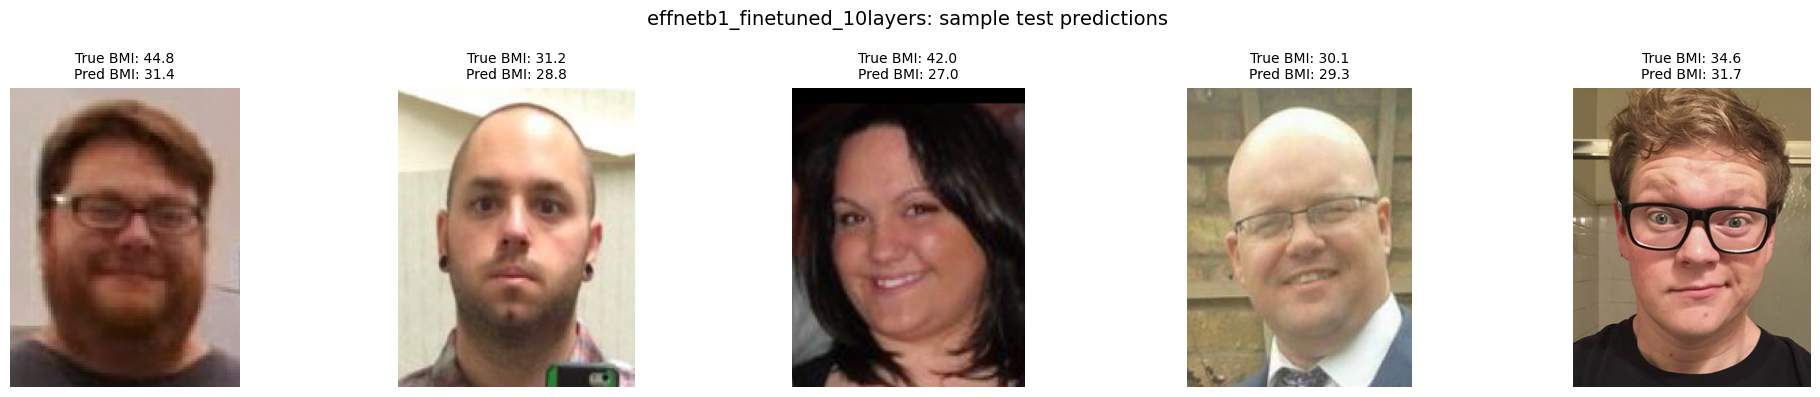

In [15]:
display_prediction_samples(test_df, predictions['test'], 'effnetb1_finetuned_10layers: sample test predictions')

## Experiment 2: ResNet50 Transfer Learning

This repeats the same Keras transfer-learning structure with a ResNet50 backbone. The goal is to compare a different pretrained architecture while keeping the training/evaluation pattern the same.


In [16]:
transfer_configs = [
    {
        'name': 'ResNet50_FineTuned_10Layers',
        'backbone': 'resnet50',
        'unfreeze_last': 10,
        'learning_rate': 1e-4,
        'optimizer': 'adam',
        'epochs': 15,
        'dropout': 0.25,
        'dense_units': 64,
    }
]

results_transfer = []
histories_transfer = {}

for cfg in transfer_configs:
    print(f"\nTraining {cfg['name']}...")
    experiment_2_model, history, result, predictions = run_transfer_experiment(cfg)
    histories_transfer[cfg['name']] = history
    results_transfer.append(result)

results_df_exp2 = pd.DataFrame(results_transfer)
display(results_df_exp2.round(4))

experiment_2_nn_run_id = f'{RUN_TAG}_experiment_2_resnet50_10layers'
save_transfer_experiment(experiment_2_nn_run_id, 'resnet50_finetuned_10layers', transfer_configs[0], experiment_2_model, results_transfer[0], predictions)



Training ResNet50_FineTuned_10Layers...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50: 175 layers


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 246, 246,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 120, 120,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 120, 120,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 120, 120,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 122, 122,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 60, 60,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 60, 60,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 60, 60,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 60, 60,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 60, 60,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 60, 60,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 60, 60,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 60, 60,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 60, 60,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 60, 60,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 60, 60,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 4,465,664 (17.04 MB)

...

 Non-trainable params: 19,122,048 (72.94 MB)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 33s 270ms/step - loss: 16.1605 - mae: 16.6544 - rmse: 20.5147 - val_loss: 8.1405 - val_mae: 8.6281 - val_rmse: 10.6397 - learning_rate: 1.0000e-04
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - loss: 5.2066 - mae: 5.6848 - rmse: 7.6795 - val_loss: 6.8722 - val_mae: 7.3573 - val_rmse: 9.6607 - learning_rate: 1.0000e-04
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 206ms/step - loss: 4.4977 - mae: 4.9747 - rmse: 6.7450 - val_loss: 7.4792 - val_mae: 7.9640 - val_rmse: 10.1211 - learning_rate: 1.0000e-04
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step - loss: 4.0383 - mae: 4.5115 - rmse: 6.1632 - val_loss: 6.1864 - val_mae: 6.6672 - val_rmse: 8.7593 - learning_rate: 1.0000e-04
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - loss: 3.6854 - mae: 4.1565 - rmse: 5.7638 - val_loss: 4.6062 - val_mae: 5.0830 - val_rmse: 6.9716 - learning_rate: 1.0000e-04
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - loss: 3.4455 - mae: 3.9153 - rmse: 

,model,backbone,unfreeze_last,train_loss,train_mae,train_rmse,train_pearson_r,best_val_loss,best_val_mae,best_val_rmse,val_pearson_r,test_loss,test_mae,test_rmse,test_pearson_r,inference_time_per_image_sec,training_time_sec
0,ResNet50_FineTuned_10Layers,resnet50,10,1.9297,2.3805,3.5308,0.9011,4.3422,4.8184,6.4906,0.5896,5.1439,5.6204,8.1811,0.526,0.0601,276.475


Saved Keras model to: /content/drive/MyDrive/ML2 Final Project/model_outputs/20260522_073954_experiment_2_resnet50_10layers.keras


,model,method,backbone,estimator,split,n,mae,rmse,pearson_r,pearson_male,pearson_female,notes
3,resnet50_finetuned_10layers,transfer_learning_cnn,resnet50,linear_regression_head,train,2635,2.3805,3.5308,0.9011,0.9127,0.8858,training split fit check
4,resnet50_finetuned_10layers,transfer_learning_cnn,resnet50,linear_regression_head,val,575,4.8184,6.4980,0.5896,0.6283,0.5369,best validation checkpoint
5,resnet50_finetuned_10layers,transfer_learning_cnn,resnet50,linear_regression_head,test,752,5.6204,8.1811,0.5260,0.6023,0.4255,selected by validation loss


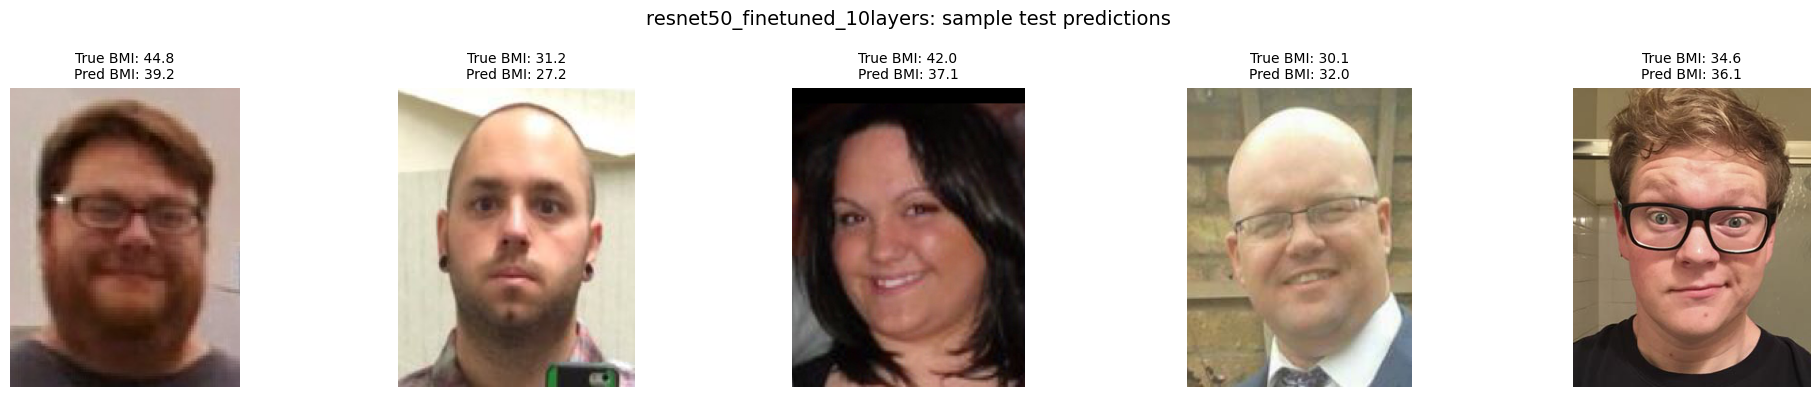

In [17]:
display_prediction_samples(test_df, predictions['test'], 'resnet50_finetuned_10layers: sample test predictions')

## Experiment 3: EfficientNetB1 Deeper Fine-Tuning

This keeps EfficientNetB1 but unfreezes more layers. It tests whether adapting more of the pretrained network improves BMI prediction.


In [18]:
transfer_configs = [
    {
        'name': 'EffNetB1_FineTuned_30Layers',
        'backbone': 'efficientnetb1',
        'unfreeze_last': 30,
        'learning_rate': 5e-5,
        'optimizer': 'adam',
        'epochs': 15,
        'dropout': 0.30,
        'dense_units': 64,
    }
]

results_transfer = []
histories_transfer = {}

for cfg in transfer_configs:
    print(f"\nTraining {cfg['name']}...")
    experiment_3_model, history, result, predictions = run_transfer_experiment(cfg)
    histories_transfer[cfg['name']] = history
    results_transfer.append(result)

results_df_exp3 = pd.DataFrame(results_transfer)
display(results_df_exp3.round(4))

experiment_3_nn_run_id = f'{RUN_TAG}_experiment_3_effnetb1_30layers'
save_transfer_experiment(experiment_3_nn_run_id, 'effnetb1_finetuned_30layers', transfer_configs[0], experiment_3_model, results_transfer[0], predictions)



Training EffNetB1_FineTuned_30Layers...
EfficientNetB1: 340 layers


Model: "efficientnetb1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_6[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,575,239 (25.08 MB)

 Trainable params: 2,471,808 (9.43 MB)

...

 Non-trainable params: 4,103,431 (15.65 MB)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 219ms/step - loss: 27.8827 - mae: 28.3827 - rmse: 29.8286 - val_loss: 20.6134 - val_mae: 21.1121 - val_rmse: 23.4850 - learning_rate: 5.0000e-05
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - loss: 16.7926 - mae: 17.2873 - rmse: 20.8100 - val_loss: 8.0459 - val_mae: 8.5318 - val_rmse: 11.3900 - learning_rate: 5.0000e-05
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - loss: 9.8125 - mae: 10.2973 - rmse: 14.3610 - val_loss: 13.2357 - val_mae: 13.7304 - val_rmse: 16.3675 - learning_rate: 5.0000e-05
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 6.9854 - mae: 7.4673 - rmse: 10.2800
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - loss: 6.7161 - mae: 7.1980 - rmse: 9.8696 - val_loss: 9.3919 - val_mae: 9.8827 - val_rmse: 12.4076 - learning_rate: 5.0000e-05
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - loss: 6.0553 - mae: 6.5347 - rmse: 9.0163 -

,model,backbone,unfreeze_last,train_loss,train_mae,train_rmse,train_pearson_r,best_val_loss,best_val_mae,best_val_rmse,val_pearson_r,test_loss,test_mae,test_rmse,test_pearson_r,inference_time_per_image_sec,training_time_sec
0,EffNetB1_FineTuned_30Layers,efficientnetb1,30,4.5037,4.9775,7.0855,0.5716,5.2503,5.7346,7.6529,0.4175,6.3882,6.871,9.7058,0.3461,0.0907,231.0868


Saved Keras model to: /content/drive/MyDrive/ML2 Final Project/model_outputs/20260522_073954_experiment_3_effnetb1_30layers.keras


,model,method,backbone,estimator,split,n,mae,rmse,pearson_r,pearson_male,pearson_female,notes
6,effnetb1_finetuned_30layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,train,2635,4.9775,7.0855,0.5716,0.5971,0.5380,training split fit check
7,effnetb1_finetuned_30layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,val,575,5.7346,7.6770,0.4175,0.4339,0.3943,best validation checkpoint
8,effnetb1_finetuned_30layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,6.8710,9.7058,0.3461,0.3641,0.3244,selected by validation loss


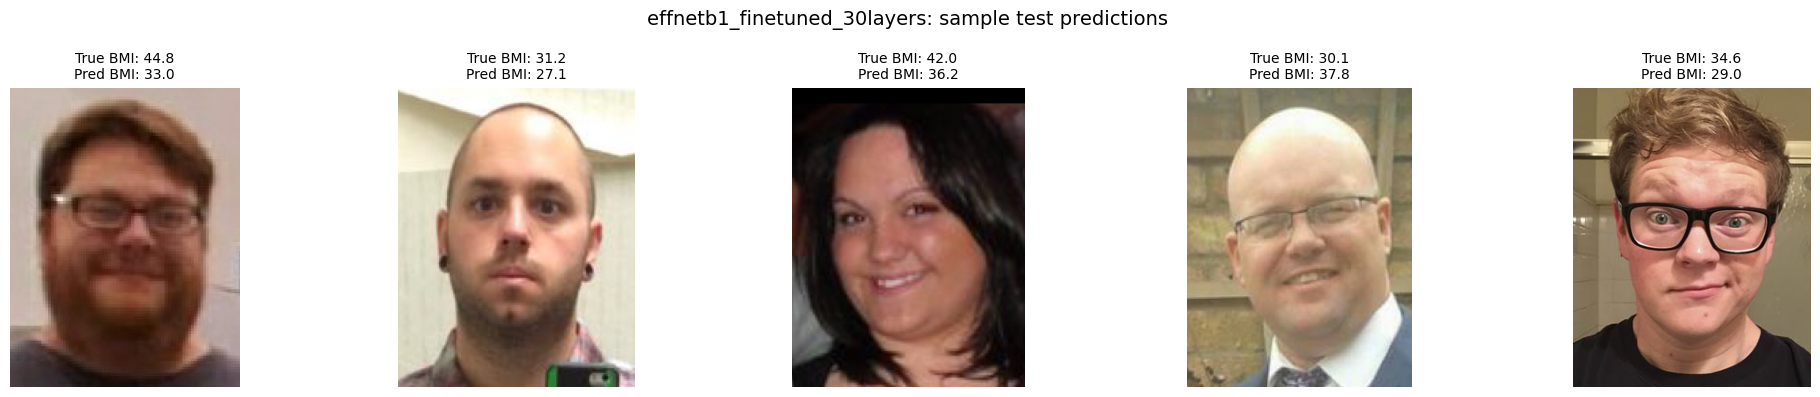

In [19]:
display_prediction_samples(test_df, predictions['test'], 'effnetb1_finetuned_30layers: sample test predictions')

## Experiment 4: Face-Pretrained Fine-Tuning

The first three neural-network experiments use ImageNet-pretrained backbones. This experiment uses a face-specific model: InceptionResnetV1 pretrained on VGGFace2 through `facenet-pytorch`. It fine-tunes the last face-model layers plus a BMI regression head, then saves a PyTorch checkpoint and logs train/validation/test metrics.


In [20]:
!pip install --upgrade --no-deps facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 102.0 MB/s eta 0:00:00


In [21]:
# Face-specific pretrained model: VGGFace2 FaceNet/InceptionResnetV1.
# This cell installs facenet-pytorch if Colab does not already have it.
try:
    from facenet_pytorch import InceptionResnetV1, fixed_image_standardization
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'facenet-pytorch'])
    from facenet_pytorch import InceptionResnetV1, fixed_image_standardization

keras.backend.clear_session()

FACE_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FACE_INPUT_SIZE = 160
FACE_BATCH_SIZE = 32
FACE_NUM_WORKERS = 0

face_tfms_train = transforms.Compose([
    transforms.Resize((FACE_INPUT_SIZE, FACE_INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    fixed_image_standardization,
])
face_tfms_eval = transforms.Compose([
    transforms.Resize((FACE_INPUT_SIZE, FACE_INPUT_SIZE)),
    transforms.ToTensor(),
    fixed_image_standardization,
])


class FaceBMIDataset(Dataset):
    def __init__(self, frame, transform, target_mean=None, target_std=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.target_mean = target_mean
        self.target_std = target_std

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        x = self.transform(img)
        bmi = float(row['bmi'])
        y = (bmi - self.target_mean) / self.target_std if self.target_mean is not None else bmi
        return {'image': x, 'target': torch.tensor(y, dtype=torch.float32), 'bmi': bmi}


train_face_loader = DataLoader(
    FaceBMIDataset(train_df, face_tfms_train, target_mean, target_std),
    batch_size=FACE_BATCH_SIZE,
    shuffle=True,
    num_workers=FACE_NUM_WORKERS,
)
train_face_eval_loader = DataLoader(
    FaceBMIDataset(train_df, face_tfms_eval, target_mean, target_std),
    batch_size=FACE_BATCH_SIZE,
    shuffle=False,
    num_workers=FACE_NUM_WORKERS,
)
val_face_loader = DataLoader(
    FaceBMIDataset(val_df, face_tfms_eval, target_mean, target_std),
    batch_size=FACE_BATCH_SIZE,
    shuffle=False,
    num_workers=FACE_NUM_WORKERS,
)
test_face_loader = DataLoader(
    FaceBMIDataset(test_df, face_tfms_eval, target_mean, target_std),
    batch_size=FACE_BATCH_SIZE,
    shuffle=False,
    num_workers=FACE_NUM_WORKERS,
)


class FaceBMIRegressor(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()
        self.backbone = InceptionResnetV1(pretrained='vggface2', classify=False)
        for p in self.backbone.parameters():
            p.requires_grad = False
        for module_name in ['mixed_7a', 'repeat_3', 'block8', 'last_linear', 'last_bn']:
            module = getattr(self.backbone, module_name, None)
            if module is not None:
                for p in module.parameters():
                    p.requires_grad = True
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        emb = self.backbone(x)
        return self.head(emb).squeeze(1)


@torch.no_grad()
def predict_face_model(model, loader):
    model.eval()
    preds = []
    for batch in loader:
        x = batch['image'].to(FACE_DEVICE)
        pred_z = model(x).detach().cpu().numpy()
        preds.extend(pred_z * target_std + target_mean)
    return np.asarray(preds)


@torch.no_grad()
def evaluate_face_loss(model, loader, criterion):
    model.eval()
    losses = []
    for batch in loader:
        x = batch['image'].to(FACE_DEVICE)
        y = batch['target'].to(FACE_DEVICE)
        pred = model(x)
        losses.append(criterion(pred, y).item())
    return float(np.mean(losses))


def train_face_epoch(model, loader, optimizer, criterion, epoch, epochs):
    model.train()
    losses = []
    try:
        from tqdm.auto import tqdm
        iterator = tqdm(loader, desc=f'Face model epoch {epoch}/{epochs}', leave=False)
    except ModuleNotFoundError:
        iterator = loader
    for batch in iterator:
        x = batch['image'].to(FACE_DEVICE)
        y = batch['target'].to(FACE_DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if hasattr(iterator, 'set_postfix'):
            iterator.set_postfix(loss=f'{np.mean(losses):.4f}')
    return float(np.mean(losses))


face_configs = [
    {
        'name': 'VGGFace2_FaceNet_FineTuned',
        'pretrained_source': 'vggface2',
        'epochs': 12,
        'learning_rate': 1e-4,
        'weight_decay': 1e-4,
        'dropout': 0.30,
    }
]

results_face = []
histories_face = {}

for cfg in face_configs:
    print(f"\nTraining {cfg['name']}...")
    face_model = FaceBMIRegressor(dropout=cfg['dropout']).to(FACE_DEVICE)
    criterion = nn.SmoothL1Loss(beta=0.5)
    optimizer = torch.optim.AdamW(
        [p for p in face_model.parameters() if p.requires_grad],
        lr=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
    )

    best_state = None
    best_val_r = -np.inf
    face_history = []
    for epoch in range(1, cfg['epochs'] + 1):
        train_loss = train_face_epoch(face_model, train_face_loader, optimizer, criterion, epoch, cfg['epochs'])
        val_loss = evaluate_face_loss(face_model, val_face_loader, criterion)
        val_pred_epoch = predict_face_model(face_model, val_face_loader)
        val_metrics = metric_row(cfg['name'], 'val', val_df, val_pred_epoch)
        face_history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_mae': val_metrics['mae'],
            'val_rmse': val_metrics['rmse'],
            'val_pearson_r': val_metrics['pearson_r'],
        })
        print(
            f"Epoch {epoch}/{cfg['epochs']} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f} "
            f"- val_mae: {val_metrics['mae']:.3f} - val_rmse: {val_metrics['rmse']:.3f} "
            f"- val_pearson_r: {val_metrics['pearson_r']:.4f}"
        )
        if val_metrics['pearson_r'] > best_val_r:
            best_val_r = val_metrics['pearson_r']
            best_state = {k: v.detach().cpu().clone() for k, v in face_model.state_dict().items()}

    face_model.load_state_dict(best_state)
    histories_face[cfg['name']] = pd.DataFrame(face_history)

    face_train_pred = predict_face_model(face_model, train_face_eval_loader)
    face_val_pred = predict_face_model(face_model, val_face_loader)
    face_test_pred = predict_face_model(face_model, test_face_loader)
    train_loss = evaluate_face_loss(face_model, train_face_eval_loader, criterion)
    val_loss = evaluate_face_loss(face_model, val_face_loader, criterion)
    test_loss = evaluate_face_loss(face_model, test_face_loader, criterion)

    face_train_metrics = metric_row(cfg['name'], 'train', train_df, face_train_pred)
    face_val_metrics = metric_row(cfg['name'], 'val', val_df, face_val_pred)
    face_test_metrics = metric_row(cfg['name'], 'test', test_df, face_test_pred)
    results_face.append({
        'model': cfg['name'],
        'pretrained_source': cfg['pretrained_source'],
        'train_loss': train_loss,
        'train_mae': face_train_metrics['mae'],
        'train_rmse': face_train_metrics['rmse'],
        'train_pearson_r': face_train_metrics['pearson_r'],
        'best_val_loss': histories_face[cfg['name']]['val_loss'].min(),
        'best_val_mae': histories_face[cfg['name']]['val_mae'].min(),
        'best_val_rmse': histories_face[cfg['name']]['val_rmse'].min(),
        'best_val_pearson_r': histories_face[cfg['name']]['val_pearson_r'].max(),
        'test_loss': test_loss,
        'test_mae': face_test_metrics['mae'],
        'test_rmse': face_test_metrics['rmse'],
        'test_pearson_r': face_test_metrics['pearson_r'],
    })

results_face_df = pd.DataFrame(results_face)
display(results_face_df.round(4))

experiment_4_face_run_id = f'{RUN_TAG}_experiment_4_vggface2_facenet'
face_checkpoint_path = MODEL_DIR / f'{experiment_4_face_run_id}.pt'
torch.save({
    'model_state_dict': face_model.state_dict(),
    'config': face_configs[0],
    'target_mean': target_mean,
    'target_std': target_std,
    'input_size': FACE_INPUT_SIZE,
    'run_id': experiment_4_face_run_id,
}, face_checkpoint_path)
print(f'Saved face-pretrained PyTorch checkpoint to: {face_checkpoint_path}')

face_metadata = {
    'method': 'face_pretrained_finetuned_cnn',
    'backbone': 'facenet_inceptionresnetv1',
    'pretrained_source': 'vggface2',
    'estimator': 'linear_regression_head',
    'input_size': FACE_INPUT_SIZE,
}
face_config = {
    'training_config': face_configs[0],
    'loss': 'SmoothL1Loss(beta=0.5)',
    'target_standardized': True,
    'saved_model_path': str(face_checkpoint_path),
    'result_summary': results_face[0],
}
add_result('vggface2_facenet_finetuned', 'train', train_df, face_train_pred, notes='face-pretrained fine-tuning', run_id=experiment_4_face_run_id, metadata=face_metadata, config=face_config)
add_result('vggface2_facenet_finetuned', 'val', val_df, face_val_pred, notes='face-pretrained fine-tuning', run_id=experiment_4_face_run_id, metadata=face_metadata, config=face_config)
add_result('vggface2_facenet_finetuned', 'test', test_df, face_test_pred, notes='selected by validation Pearson r', run_id=experiment_4_face_run_id, metadata=face_metadata, config=face_config)
show_run(experiment_4_face_run_id)



Training VGGFace2_FaceNet_FineTuned...


  0%|          | 0.00/107M [00:00<?, ?B/s]

Face model epoch 1/12:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 1/12 - loss: 0.5114 - val_loss: 0.4537 - val_mae: 5.328 - val_rmse: 7.207 - val_pearson_r: 0.5870


Face model epoch 2/12:   0%|          | 0/83 [00:00<?, ?it/s]

...

Face model epoch 12/12:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 12/12 - loss: 0.1353 - val_loss: 0.4045 - val_mae: 4.868 - val_rmse: 6.509 - val_pearson_r: 0.6238


,model,pretrained_source,train_loss,train_mae,train_rmse,train_pearson_r,best_val_loss,best_val_mae,best_val_rmse,best_val_pearson_r,test_loss,test_mae,test_rmse,test_pearson_r
0,VGGFace2_FaceNet_FineTuned,vggface2,0.1363,2.3675,3.54,0.9037,0.3645,4.5258,6.0395,0.6509,0.4558,5.3174,7.5285,0.577


Saved face-pretrained PyTorch checkpoint to: /content/drive/MyDrive/ML2 Final Project/model_outputs/20260522_073954_experiment_4_vggface2_facenet.pt


,model,method,backbone,estimator,split,n,mae,rmse,pearson_r,pearson_male,pearson_female,notes
9,vggface2_facenet_finetuned,face_pretrained_finetuned_cnn,facenet_inceptionresnetv1,linear_regression_head,train,2635,2.3675,3.5400,0.9037,0.9003,0.9083,face-pretrained fine-tuning
10,vggface2_facenet_finetuned,face_pretrained_finetuned_cnn,facenet_inceptionresnetv1,linear_regression_head,val,575,4.5833,6.0395,0.6509,0.7053,0.5787,face-pretrained fine-tuning
11,vggface2_facenet_finetuned,face_pretrained_finetuned_cnn,facenet_inceptionresnetv1,linear_regression_head,test,752,5.3174,7.5285,0.5770,0.5975,0.5517,selected by validation Pearson r


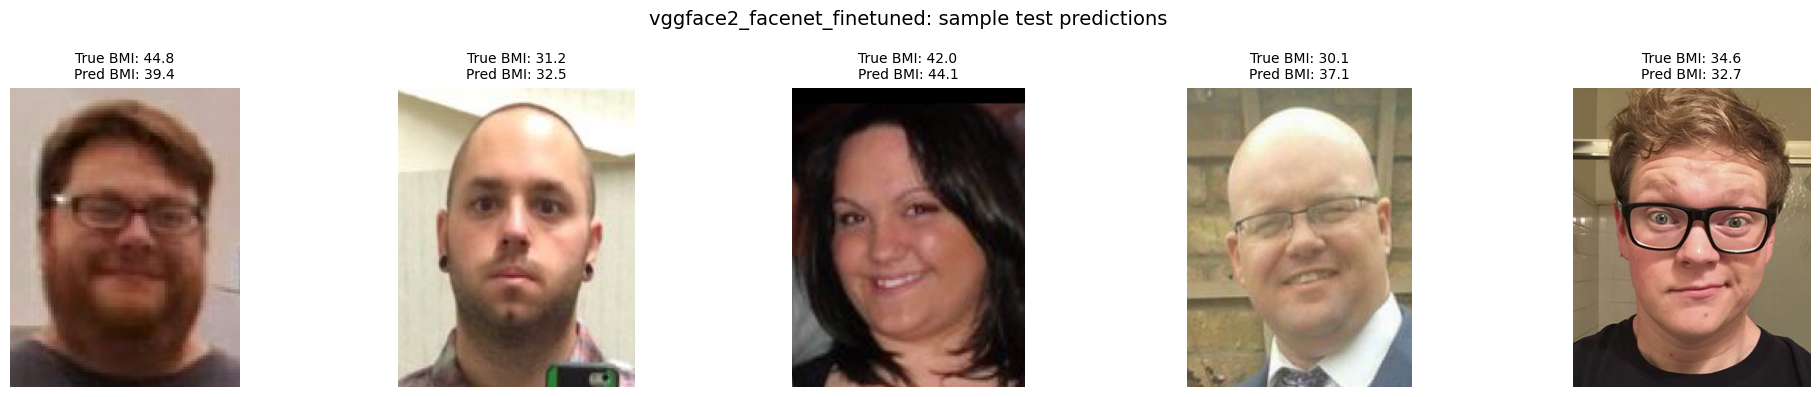

In [22]:
display_prediction_samples(test_df, face_test_pred, 'vggface2_facenet_finetuned: sample test predictions')

## Final Comparison, Paper-Style Pairwise Evaluation, and Error Analysis

This section keeps two comparisons separate:

- BMI regression: Pearson `r`, MAE, and RMSE on the available image test subset, with subgroup Pearson using the dataset's true gender labels.
- Paper-style ranking: pairwise accuracy from BMI predictions, formatted like the gender and BMI-difference bar charts. This does not train or use a predicted-gender label.


,run_id,model,method,backbone,estimator,split,n,test_rows,paper_test_rows,missing_test_images,evaluation_scope,mae,rmse,pearson_r,pearson_male,pearson_female,notes
0,20260521_081539_experiment_4_vggface2_facenet,vggface2_facenet_finetuned,face_pretrained_finetuned_cnn,facenet_inceptionresnetv1,linear_regression_head,test,752,752,NaN,NaN,NaN,5.3758,7.7771,0.5988,0.6050,0.5901,selected by validation Pearson r
1,20260522_073954_experiment_4_vggface2_facenet,vggface2_facenet_finetuned,face_pretrained_finetuned_cnn,facenet_inceptionresnetv1,linear_regression_head,test,752,752,838.0,86.0,available-image-test-subset,5.3174,7.5285,0.5770,0.5975,0.5517,selected by validation Pearson r
2,20260521_072325_experiment_2_resnet50_10layers,resnet50_finetuned_10layers,transfer_learning_cnn,resnet50,linear_regression_head,test,752,752,NaN,NaN,NaN,5.5987,8.1546,0.5292,0.6055,0.4282,selected by validation loss
3,20260522_073954_experiment_2_resnet50_10layers,resnet50_finetuned_10layers,transfer_learning_cnn,resnet50,linear_regression_head,test,752,752,838.0,86.0,available-image-test-subset,5.6204,8.1811,0.5260,0.6023,0.4255,selected by validation loss
4,20260522_073954_experiment_3_effnetb1_30layers,effnetb1_finetuned_30layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,838.0,86.0,available-image-test-subset,6.8710,9.7058,0.3461,0.3641,0.3244,selected by validation loss
5,20260521_072325_experiment_3_effnetb1_30layers,effnetb1_finetuned_30layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,NaN,NaN,NaN,6.8710,9.7058,0.3461,0.3641,0.3244,selected by validation loss
6,20260521_072325_experiment_1_effnetb1_10layers,effnetb1_finetuned_10layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,NaN,NaN,NaN,6.8158,9.6252,0.3210,0.3807,0.2390,selected by validation loss
7,20260522_073954_experiment_1_effnetb1_10layers,effnetb1_finetuned_10layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,838.0,86.0,available-image-test-subset,6.8158,9.6252,0.3210,0.3807,0.2390,selected by validation loss
8,20260521_062234_experiment_1_effnetb1_finetuned,effnetb1_finetuned,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,NaN,NaN,NaN,6.8158,9.6252,0.3210,0.3807,0.2390,selected by validation loss
9,20260520_184122_gender_mean,gender_mean,baseline,NaN,group_mean,test,752,752,NaN,NaN,NaN,7.0623,9.3050,-0.0529,-0.0000,NaN,metadata-only sanity baseline


,run_id,model,method,backbone,estimator,split,n,test_rows,paper_test_rows,missing_test_images,evaluation_scope,mae,rmse,pearson_r,pearson_male,pearson_female,notes
0,20260521_081539_experiment_4_vggface2_facenet,vggface2_facenet_finetuned,face_pretrained_finetuned_cnn,facenet_inceptionresnetv1,linear_regression_head,test,752,752,NaN,NaN,NaN,5.3758,7.7771,0.5988,0.6050,0.5901,selected by validation Pearson r
1,20260521_072325_experiment_2_resnet50_10layers,resnet50_finetuned_10layers,transfer_learning_cnn,resnet50,linear_regression_head,test,752,752,NaN,NaN,NaN,5.5987,8.1546,0.5292,0.6055,0.4282,selected by validation loss
2,20260522_073954_experiment_3_effnetb1_30layers,effnetb1_finetuned_30layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,838.0,86.0,available-image-test-subset,6.8710,9.7058,0.3461,0.3641,0.3244,selected by validation loss
3,20260521_072325_experiment_1_effnetb1_10layers,effnetb1_finetuned_10layers,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,NaN,NaN,NaN,6.8158,9.6252,0.3210,0.3807,0.2390,selected by validation loss
4,20260521_062234_experiment_1_effnetb1_finetuned,effnetb1_finetuned,transfer_learning_cnn,efficientnetb1,linear_regression_head,test,752,752,NaN,NaN,NaN,6.8158,9.6252,0.3210,0.3807,0.2390,selected by validation loss
5,20260520_184122_gender_mean,gender_mean,baseline,NaN,group_mean,test,752,752,NaN,NaN,NaN,7.0623,9.3050,-0.0529,-0.0000,NaN,metadata-only sanity baseline
6,20260520_184122_train_mean,train_mean,baseline,NaN,mean,test,752,752,NaN,NaN,NaN,7.0453,9.2863,NaN,NaN,NaN,constant sanity baseline


Pairwise comparison from: /content/drive/MyDrive/ML2 Final Project/model_outputs/experiments/predictions/20260521_081539_experiment_4_vggface2_facenet_test_predictions.csv
Gender labels below are dataset labels, not predicted gender labels.


,sample,ALL,M-M,F-F,M-F,0.5-5.5,5.5-10.5,10.5-15.5
0,n_pairs,900,300,300,300,300,300,300


,Model,ALL,M-M,F-F,M-F
0,Face-to-BMI (Paper),71.0,73.7,68.7,70.7
1,vggface2_facenet_finetuned,73.3,72.7,73.0,74.3


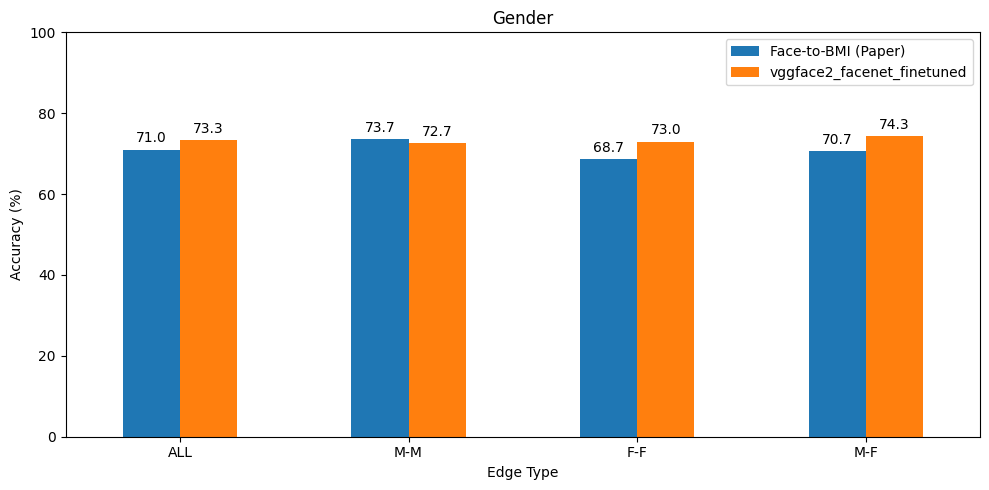

,Model,0.5-5.5,5.5-10.5,10.5-15.5
0,Face-to-BMI (Paper),56.2,78.9,82.7
1,vggface2_facenet_finetuned,61.0,75.7,83.3


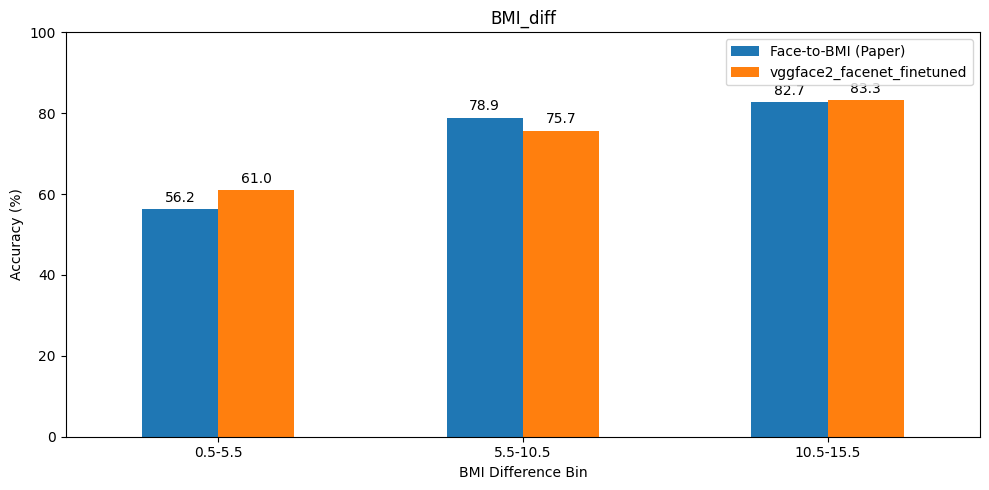

Saved pairwise charts to: /content/drive/MyDrive/ML2 Final Project/model_outputs/experiments/paper_style_pairwise


,name,bmi,gender,split,pair_id,model,run_id,pred_bmi,error,abs_error
728,img_4180.bmp,85.987061,Female,test,2090,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,30.248407,-55.738653,55.738653
565,img_4008.bmp,84.984889,Male,test,2004,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,34.435040,-50.549849,50.549849
729,img_4181.bmp,72.084961,Female,test,2090,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,26.686396,-45.398565,45.398565
254,img_3648.bmp,68.618441,Male,test,1824,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,26.698359,-41.920083,41.920083
436,img_3858.bmp,72.604318,Female,test,1929,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,31.921041,-40.683277,40.683277
619,img_4064.bmp,60.105733,Male,test,2032,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,24.695036,-35.410697,35.410697
595,img_4040.bmp,61.649679,Female,test,2020,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,28.415855,-33.233823,33.233823
587,img_4032.bmp,66.556213,Male,test,2016,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,34.758549,-31.797664,31.797664
639,img_4084.bmp,64.189941,Female,test,2042,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,32.433807,-31.756134,31.756134
230,img_3622.bmp,63.093642,Female,test,1811,effnetb1_finetuned_10layers,20260522_073954_experiment_1_effnetb1_10layers,31.415892,-31.677750,31.677750


,n,mae,bias,pearson_r
gender,,,,
Female,325,6.9979,-3.4540,0.2390
Male,427,6.6773,-4.2415,0.3807


All experiment results are saved at: /content/drive/MyDrive/ML2 Final Project/model_outputs/experiments/experiment_results.csv


In [25]:
# Reload every result saved across notebook runs and rank final test performance.
test_comparison = compare_results(split='test', sort_by='pearson_r')
display(test_comparison)

# Best saved result per model name.
display(best_by_model(split='test', metric='pearson_r'))

PAPER_PAIRWISE_GENDER = {
    'Model': 'Face-to-BMI (Paper)',
    'ALL': 71.0,
    'M-M': 73.7,
    'F-F': 68.7,
    'M-F': 70.7,
}
PAPER_PAIRWISE_BMI_DIFF = {
    'Model': 'Face-to-BMI (Paper)',
    '0.5-5.5': 56.2,
    '5.5-10.5': 78.9,
    '10.5-15.5': 82.7,
}
EDGE_ORDER = ['ALL', 'M-M', 'F-F', 'M-F']
BMI_DIFF_ORDER = ['0.5-5.5', '5.5-10.5', '10.5-15.5']


def build_pairwise_edges(predictions, min_bmi_diff=0.5, max_bmi_diff=15.5):
    required = {'name', 'bmi', 'gender', 'pred_bmi'}
    missing = required.difference(predictions.columns)
    if missing:
        raise ValueError(f'Prediction file is missing columns: {sorted(missing)}')

    rows = predictions[['name', 'bmi', 'gender', 'pred_bmi']].copy().reset_index(drop=True)
    rows['gender'] = rows['gender'].astype(str).str.strip()
    left_idx, right_idx = np.triu_indices(len(rows), k=1)
    left = rows.iloc[left_idx].reset_index(drop=True)
    right = rows.iloc[right_idx].reset_index(drop=True)

    true_diff = left['bmi'].to_numpy(float) - right['bmi'].to_numpy(float)
    pred_diff = left['pred_bmi'].to_numpy(float) - right['pred_bmi'].to_numpy(float)
    bmi_diff = np.abs(true_diff)

    left_gender = left['gender'].to_numpy()
    right_gender = right['gender'].to_numpy()
    edge_type = np.where(
        (left_gender == 'Male') & (right_gender == 'Male'), 'M-M',
        np.where((left_gender == 'Female') & (right_gender == 'Female'), 'F-F', 'M-F')
    )

    true_sign = np.sign(true_diff)
    pred_sign = np.sign(pred_diff)
    # If a model gives exactly equal BMI predictions, count that pair as a half-correct no-decision.
    correct_score = np.where(pred_sign == 0, 0.5, (pred_sign == true_sign).astype(float))

    pairs = pd.DataFrame({
        'left_name': left['name'],
        'right_name': right['name'],
        'edge_type': edge_type,
        'bmi_diff': bmi_diff,
        'correct_score': correct_score,
    })
    return pairs[(pairs['bmi_diff'] > min_bmi_diff) & (pairs['bmi_diff'] <= max_bmi_diff)].reset_index(drop=True)


def sample_pairs_like_paper(pairs, pairs_per_edge_bin=20, random_state=SEED):
    # The paper sampled 20 pairs from each 1-BMI-wide bin, separately for M-M, F-F, and M-F.
    fine_edges = np.arange(0.5, 16.5, 1.0)
    fine_labels = [f'{lo:.1f}-{hi:.1f}' for lo, hi in zip(fine_edges[:-1], fine_edges[1:])]
    work = pairs.copy()
    work['fine_bmi_bin'] = pd.cut(work['bmi_diff'], bins=fine_edges, labels=fine_labels, right=True)
    work = work.dropna(subset=['fine_bmi_bin'])

    sampled = []
    for edge_i, edge_type in enumerate(['M-M', 'F-F', 'M-F']):
        for bin_i, fine_bin in enumerate(fine_labels):
            part = work[(work['edge_type'] == edge_type) & (work['fine_bmi_bin'] == fine_bin)]
            if part.empty:
                continue
            n = min(pairs_per_edge_bin, len(part))
            sampled.append(part.sample(n=n, random_state=random_state + edge_i * 100 + bin_i))

    if not sampled:
        return work.iloc[0:0].copy()
    return pd.concat(sampled, ignore_index=True)


def summarize_pairwise_by_gender(sampled_pairs):
    values = {'ALL': sampled_pairs['correct_score'].mean() * 100}
    for edge_type in ['M-M', 'F-F', 'M-F']:
        part = sampled_pairs[sampled_pairs['edge_type'] == edge_type]
        values[edge_type] = part['correct_score'].mean() * 100 if len(part) else np.nan
    return values


def summarize_pairwise_by_bmi_diff(sampled_pairs):
    values = {}
    bins = [(0.5, 5.5, '0.5-5.5'), (5.5, 10.5, '5.5-10.5'), (10.5, 15.5, '10.5-15.5')]
    for lo, hi, label in bins:
        part = sampled_pairs[(sampled_pairs['bmi_diff'] > lo) & (sampled_pairs['bmi_diff'] <= hi)]
        values[label] = part['correct_score'].mean() * 100 if len(part) else np.nan
    return values


def pairwise_counts(sampled_pairs):
    count_row = {'sample': 'n_pairs'}
    count_row.update({'ALL': len(sampled_pairs)})
    for edge_type in ['M-M', 'F-F', 'M-F']:
        count_row[edge_type] = int(sampled_pairs['edge_type'].eq(edge_type).sum())
    for lo, hi, label in [(0.5, 5.5, '0.5-5.5'), (5.5, 10.5, '5.5-10.5'), (10.5, 15.5, '10.5-15.5')]:
        count_row[label] = int(((sampled_pairs['bmi_diff'] > lo) & (sampled_pairs['bmi_diff'] <= hi)).sum())
    return pd.DataFrame([count_row])


def plot_paper_style_bars(table, columns, title, xlabel, save_path):
    plot_df = table.set_index('Model')[columns]
    ax = plot_df.T.plot(kind='bar', figsize=(10, 5), rot=0)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


def select_best_test_prediction_path():
    results = load_experiment_results()
    if leaderboard:
        results = pd.concat([results, pd.DataFrame(leaderboard)], ignore_index=True)
    if results.empty:
        return None, None
    results = results[results['split'].eq('test')].copy()
    results = results.dropna(subset=['prediction_path'])
    results = results[results['prediction_path'].apply(lambda p: Path(str(p)).exists())]
    results = results.sort_values('pearson_r', ascending=False, na_position='last')
    if results.empty:
        return None, None
    best = results.iloc[0]
    return Path(best['prediction_path']), str(best['model'])


def display_paper_style_pairwise_comparison(prediction_path=None, model_label=None):
    if prediction_path is None:
        prediction_path, inferred_label = select_best_test_prediction_path()
        model_label = model_label or inferred_label
    if prediction_path is None:
        print('No saved test prediction file is available yet. Run a model cell first.')
        return None

    predictions = pd.read_csv(prediction_path)
    model_label = model_label or predictions['model'].iloc[0]
    pairs = build_pairwise_edges(predictions)
    sampled_pairs = sample_pairs_like_paper(pairs)
    if sampled_pairs.empty:
        print('No eligible test pairs were available for paper-style pairwise evaluation.')
        return None

    gender_model = {'Model': model_label, **summarize_pairwise_by_gender(sampled_pairs)}
    bmi_diff_model = {'Model': model_label, **summarize_pairwise_by_bmi_diff(sampled_pairs)}

    gender_table = pd.DataFrame([PAPER_PAIRWISE_GENDER, gender_model]).round(1)
    bmi_diff_table = pd.DataFrame([PAPER_PAIRWISE_BMI_DIFF, bmi_diff_model]).round(1)

    print(f'Pairwise comparison from: {prediction_path}')
    print('Gender labels below are dataset labels, not predicted gender labels.')
    display(pairwise_counts(sampled_pairs))

    display(gender_table)
    gender_chart_path = PAIRWISE_DIR / f'{RUN_TAG}_{slugify(model_label)}_gender_pairwise_accuracy.png'
    plot_paper_style_bars(gender_table, EDGE_ORDER, 'Gender', 'Edge Type', gender_chart_path)

    display(bmi_diff_table)
    bmi_chart_path = PAIRWISE_DIR / f'{RUN_TAG}_{slugify(model_label)}_bmi_diff_pairwise_accuracy.png'
    plot_paper_style_bars(bmi_diff_table, BMI_DIFF_ORDER, 'BMI_diff', 'BMI Difference Bin', bmi_chart_path)

    print(f'Saved pairwise charts to: {PAIRWISE_DIR}')
    return {
        'sampled_pairs': sampled_pairs,
        'gender_table': gender_table,
        'bmi_diff_table': bmi_diff_table,
        'gender_chart_path': gender_chart_path,
        'bmi_chart_path': bmi_chart_path,
    }


pairwise_outputs = display_paper_style_pairwise_comparison()

# Error analysis for Experiment 1, if that cell has been run.
if 'experiment_1_nn_run_id' in globals():
    pred_path = PREDICTION_DIR / f'{experiment_1_nn_run_id}_test_predictions.csv'
    predictions = pd.read_csv(pred_path)
    display(predictions.assign(abs_error=lambda x: x['error'].abs()).sort_values('abs_error', ascending=False).head(20))

    error_by_group = predictions.assign(abs_error=lambda x: x['error'].abs()).groupby('gender').agg(
        n=('error', 'size'),
        mae=('abs_error', 'mean'),
        bias=('error', 'mean'),
        pearson_r=('pred_bmi', lambda s: pearson_r(predictions.loc[s.index, 'bmi'], s)),
    ).round(4)
    display(error_by_group)
else:
    print('Run Experiment 1 before fine-tuned error analysis. The comparison table above can still show saved prior results.')

print(f'All experiment results are saved at: {RESULTS_PATH}')


BMI Diff: When BMI diff is larger, we want higher accuracy. When BMI diff is less, we are ok with lower accuracy. 